# **Instalasi Library (Jalankan Sekali)**

In [ ]:
print("Menginstal library yang diperlukan...")
print("="*60)

# Install LightGBM dengan GPU support
import subprocess
import sys
import numpy as np

try:
    # Di Colab dengan runtime GPU, pip install lightgbm biasanya
    # secara otomatis menginstal versi yang mendukung GPU
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    print("LightGBM berhasil diinstal. Pastikan Anda telah memilih runtime GPU di Colab (Runtime > Change runtime type) untuk memanfaatkan dukungan GPU.")

    # Verifikasi sederhana apakah LightGBM memiliki dukungan GPU
    try:
        import lightgbm as lgb
        # Untuk memverifikasi, kita bisa mencoba membangun model dummy dengan device='gpu'
        X_dummy = np.random.rand(10, 10)  # Data dummy kecil
        y_dummy = np.random.randint(0, 2, 10)  # Label dummy kecil
        model = lgb.LGBMClassifier(device='gpu', n_estimators=1, verbosity=-1)
        model.fit(X_dummy, y_dummy)
        print("Verifikasi dukungan GPU LightGBM berhasil! (Model dummy berjalan dengan 'gpu' device)")
    except Exception as gpu_check_e:
        print(f"LightGBM terinstal, namun verifikasi dukungan GPU gagal: {gpu_check_e}")
        print("Ini mungkin karena Anda tidak menggunakan runtime GPU atau ada masalah konfigurasi lainnya.")
except Exception as e:
    print(f"Gagal menginstal LightGBM dengan dukungan GPU otomatis: {e}")
    print("Melanjutkan dengan instalasi LightGBM versi CPU sebagai fallback.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])

# Install imbalanced-learn untuk sampling (jika diperlukan di masa depan)
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])

# Install Optuna untuk hyperparameter tuning (jika diperlukan)
subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])

print("Instalasi selesai!")
print("="*60)

Menginstal library yang diperlukan...
LightGBM berhasil diinstal. Pastikan Anda telah memilih runtime GPU di Colab (Runtime > Change runtime type) untuk memanfaatkan dukungan GPU.
Verifikasi dukungan GPU LightGBM berhasil! (Model dummy berjalan dengan 'gpu' device)
Instalasi selesai!


# **Import Library, Setup, dan Mount Google Drive**

####**Import Library**

In [ ]:
# Import Library untuk Data Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import psutil
import os
import gc
from datetime import datetime
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import Library untuk Machine Learning - Tree-based Models
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Import Library untuk Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer, matthews_corrcoef, confusion_matrix,
    classification_report)

# Import Library untuk Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Import Library untuk Sampling (optional, tidak dipakai untuk baseline)
from imblearn.under_sampling import RandomUnderSampler

print("Semua library berhasil diimport!")
print(f"  - TensorFlow version: {tf.__version__}")
print(f"  - XGBoost version: {xgb.__version__}")
print(f"  - LightGBM version: {lgb.__version__}")

Semua library berhasil diimport!
  - TensorFlow version: 2.19.0
  - XGBoost version: 3.2.0
  - LightGBM version: 4.6.0


####**Mount GDrive**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


####**Setup Folder**

In [ ]:
# Definisi path
DATASET_PATH = '/content/drive/My Drive/Dataset/final_dataset.parquet'
PROCESSED_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Processed_Data/'
MODELS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Models/'
RESULTS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Results/'
CHECKPOINT_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Checkpoints/'
EDA_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/EDA_Results/'

# Membuat direktori
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)

print(f"Folder setup selesai!")
print(f"\nPath dataset: {DATASET_PATH}")
print(f"\nFolder struktur:")
print(f"  - Processed Data: {PROCESSED_DIR}")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Results: {RESULTS_DIR}")
print(f"  - Checkpoints: {CHECKPOINT_DIR}")
print(f"  - EDA Results: {EDA_DIR}")

Folder setup selesai!

Path dataset: /content/drive/My Drive/Dataset/final_dataset.parquet

Folder struktur:
  - Processed Data: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/Processed_Data/
  - Models: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/Models/
  - Results: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/Results/
  - Checkpoints: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/Checkpoints/
  - EDA Results: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/EDA_Results/


# **Langkah 1: Pre-Processing Data**

###**1.1 Load Dataset**

In [ ]:
df = pd.read_parquet(DATASET_PATH)

print(f"Dataset berhasil diload!")
print(f"  - Total rows: {df.shape[0]:,}")
print(f"  - Total columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset berhasil diload!
  - Total rows: 685,671
  - Total columns: 95
  - Memory usage: 3994.50 MB


###**1.2 Inspeksi Awal**

1.2.1 Cek Kolom dan Tipe Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685671 entries, 0 to 685670
Data columns (total 95 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   device_name                           685671 non-null  object 
 1   device_mac                            685671 non-null  object 
 2   label_full                            685671 non-null  object 
 3   label1                                685671 non-null  object 
 4   label2                                685671 non-null  object 
 5   label3                                685671 non-null  object 
 6   label4                                685671 non-null  object 
 7   timestamp                             685671 non-null  object 
 8   timestamp_start                       685671 non-null  object 
 9   timestamp_end                         685671 non-null  object 
 10  log_data-ranges_avg                   685671 non-null  float64
 11  

1.2.2 Distribusi Kelas (Label2 - Original)

In [ ]:
label_col = 'label2'
class_counts_original = df[label_col].value_counts().sort_index()

print(f"\nDistribusi Kelas (8 Kategori Original):")
for label in class_counts_original.index:
    count = class_counts_original[label]
    pct = (count / len(df)) * 100
    print(f"  {label:12s}: {count:7,} ({pct:5.2f}%)")

print(f"\nTotal samples: {len(df):,}")
print(f"Jumlah kelas: {df[label_col].nunique()}")


Distribusi Kelas (8 Kategori Original):
  benign      : 400,672 (58.44%)
  bruteforce  :   6,016 ( 0.88%)
  ddos        :  56,692 ( 8.27%)
  dos         :  57,736 ( 8.42%)
  malware     :  24,177 ( 3.53%)
  mitm        :  25,490 ( 3.72%)
  recon       : 105,848 (15.44%)
  web         :   9,040 ( 1.32%)

Total samples: 685,671
Jumlah kelas: 8


In [ ]:
print(f"Persentase Kelas:")
class_pct = (class_counts_original / len(df) * 100).round(4)
print(class_pct)

Persentase Kelas:
label2
benign        58.4350
bruteforce     0.8774
ddos           8.2681
dos            8.4204
malware        3.5260
mitm           3.7175
recon         15.4371
web            1.3184
Name: count, dtype: float64


1.2.3 Menghitung Imbalance Ratio

In [ ]:
min_class = class_counts_original.min()
max_class = class_counts_original.max()
imbalance_ratio = max_class / min_class

print(f"Imbalance Ratio: 1:{imbalance_ratio:.0f}")
print(f"Kelas Mayoritas: {class_counts_original.idxmax()} ({max_class:,} samples)")
print(f"Kelas Minoritas: {class_counts_original.idxmin()} ({min_class:,} samples)")

Imbalance Ratio: 1:67
Kelas Mayoritas: benign (400,672 samples)
Kelas Minoritas: bruteforce (6,016 samples)


1.2.4 Menyimpan Distribusi Kelas

In [ ]:
class_dist_dict = {
    'counts': {str(k): int(v) for k, v in class_counts_original.to_dict().items()},
    'percentages': {str(k): float(v) for k, v in class_pct.to_dict().items()},
    'imbalance_ratio': float(imbalance_ratio),
    'majority_class': str(class_counts_original.idxmax()),
    'minority_class': str(class_counts_original.idxmin())
}

with open(os.path.join(RESULTS_DIR, 'class_distribution.json'), 'w') as f:
    json.dump(class_dist_dict, f, indent=4)

print("Distribusi kelas tersimpan!")

Distribusi kelas tersimpan!


###**1.3 Drop Kolom yang Tidak Diperlukan**

In [ ]:
# Define columns to drop (sama seperti preprocessing sebelumnya)
drop_columns = [
    # Metadata (tidak predictive)
    'device_name',        # Categorical identifier
    'device_mac',         # Unique identifier
    'timestamp',          # String timestamp
    'timestamp_start',    # String timestamp
    'timestamp_end',      # String timestamp

    # Labels (keep label2 only sebagai target)
    'label_full', 'label1', 'label3', 'label4',

    # List columns (pakai count saja, drop list-nya)
    'log_data-types',           # List of data types
    'network_ips_all',          # List of IPs
    'network_ips_dst',          # List of destination IPs
    'network_ips_src',          # List of source IPs
    'network_macs_all',         # List of MACs
    'network_macs_dst',         # List of destination MACs
    'network_macs_src',         # List of source MACs
    'network_ports_all',        # List of ports
    'network_ports_dst',        # List of destination ports
    'network_ports_src',        # List of source ports
    'network_protocols_all',    # List of protocols
    'network_protocols_dst',    # List of destination protocols
    'network_protocols_src'     # List of source protocols
]

# Verify all columns exist before dropping
existing_drop_cols = [col for col in drop_columns if col in df.columns]
missing_drop_cols = [col for col in drop_columns if col not in df.columns]

if missing_drop_cols:
    print(f"Warning: Columns not found in dataset: {missing_drop_cols}")

# Drop columns
df = df.drop(columns=existing_drop_cols)

print(f"Dropped {len(existing_drop_cols)} columns")
print(f"  - Remaining columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Tampilkan kolom yang tersisa
print(f"\n  Kolom yang tersisa ({df.shape[1]} kolom):")
print(f"    - label2: 1 kolom (target)")
print(f"    - time_window: 1 kolom (untuk split)")
print(f"    - Features: {df.shape[1] - 2} kolom")

Dropped 22 columns
  - Remaining columns: 73
  - Memory usage: 412.21 MB

  Kolom yang tersisa (73 kolom):
    - label2: 1 kolom (target)
    - time_window: 1 kolom (untuk split)
    - Features: 71 kolom


###**1.4 Konversi Tipe Data (Memory Optimization)**

In [ ]:
initial_memory = df.memory_usage(deep=True).sum() / 1024**2

# Downcast integer columns (kecuali time_window dan label2)
int_cols = df.select_dtypes(include=['int64']).columns.tolist()
exclude_int = ['time_window']  # label2 adalah string, jadi tidak perlu exclude

for col in int_cols:
    if col not in exclude_int:
        # Check if values fit in int32
        col_min = df[col].min()
        col_max = df[col].max()
        if col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
            df[col] = df[col].astype('int32')
        else:
            print(f"   {col}: Range too large for int32, keeping int64")

# Downcast float columns
float_cols = df.select_dtypes(include=['float64']).columns.tolist()
for col in float_cols:
    df[col] = df[col].astype('float32')

final_memory = df.memory_usage(deep=True).sum() / 1024**2
memory_saved = initial_memory - final_memory
memory_reduction = (memory_saved / initial_memory) * 100

print(f"Memory optimization complete!")
print(f"  - Initial memory: {initial_memory:.2f} MB")
print(f"  - Final memory: {final_memory:.2f} MB")
print(f"  - Saved: {memory_saved:.2f} MB ({memory_reduction:.1f}% reduction)")

gc.collect()  # Force garbage collection

Memory optimization complete!
  - Initial memory: 412.21 MB
  - Final memory: 226.50 MB
  - Saved: 185.71 MB (45.1% reduction)


0

###**1.5 Cek Kualitas Data & Cleaning**

1.5.1 Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({
    'Jumlah_Missing': missing,
    'Persentase_Missing': missing_pct
})
missing_df = missing_df[missing_df['Jumlah_Missing'] > 0].sort_values('Jumlah_Missing', ascending=False)

if len(missing_df) > 0:
    print(" Kolom dengan missing values:")
    print(missing_df)

    # Handle missing values
    print("\n  Menangani missing values...")
    for col in missing_df.index:
        if missing_df.loc[col, 'Persentase_Missing'] < 1.0:
            # Hapus baris dengan missing < 1%
            df = df.dropna(subset=[col])
            print(f"    - Baris dengan missing values di '{col}' dihapus")
        else:
            # Fill dengan median/mode untuk missing >= 1%
            if df[col].dtype in ['float32', 'float64', 'int32', 'int64', 'Int32']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"    - Missing values di '{col}' diisi dengan median")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"    - Missing values di '{col}' diisi dengan modus")
else:
    print("Tidak ada missing values!")

Tidak ada missing values!


1.5.2 Infinite Values

In [ ]:
# Pilih kolom numerik saja
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_counts = {}
for col in numeric_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_counts[col] = inf_count

if inf_counts:
    print(" Kolom dengan nilai infinite:")
    for col, count in inf_counts.items():
        print(f"    - {col}: {count:,}")

    print("\n  Mengganti nilai infinite dengan max/min kolom...")
    for col in inf_counts.keys():
        # Mengganti nilai np.inf dengan nilai maksimum yang valid di kolom tersebut
        df[col] = df[col].replace([np.inf], df[col][~np.isinf(df[col])].max())
        # Mengganti nilai -np.inf dengan nilai minimum yang valid di kolom tersebut
        df[col] = df[col].replace([-np.inf], df[col][~np.isinf(df[col])].min())
        print(f"    - Nilai infinite di '{col}' diperbaiki")
else:
    print(" Tidak ada nilai infinite!")

 Tidak ada nilai infinite!


1.5.3 Remove All-Zero Rows

In [ ]:
# Kolom fitur (exclude label2 dan time_window)
feature_cols = [col for col in df.columns if col not in ['label2', 'time_window']]

# Cek baris yang semua fiturnya 0
all_zero_mask = (df[feature_cols] == 0).all(axis=1)
zero_count = all_zero_mask.sum()

print(f"  Ditemukan {zero_count:,} all-zero rows ({(zero_count/len(df)*100):.2f}%)")

if zero_count > 0:
    df = df[~all_zero_mask].copy()
    print(f"  Removed {zero_count:,} invalid rows")
    print(f"  Remaining: {len(df):,} rows")
else:
    print("  Tidak ada all-zero rows")

  Ditemukan 136,798 all-zero rows (19.95%)
  Removed 136,798 invalid rows
  Remaining: 548,873 rows


##### 1.5.4 Remove Exact Duplicates (same time_window)

In [ ]:
# Kolom untuk cek duplikat (semua kolom kecuali label2)
feature_cols_with_tw = [col for col in df.columns if col not in ['label2']]

size_before = len(df)
df = df.drop_duplicates(subset=feature_cols_with_tw, keep='first')
exact_dup_removed = size_before - len(df)

print(f"  Removed {exact_dup_removed:,} exact duplicates")
print(f"  Remaining: {len(df):,} rows")

  Removed 2,231 exact duplicates
  Remaining: 546,642 rows


#####1.5.5 Remove Temporal Duplicates (different time_window)

In [ ]:
size_before_temporal = len(df)

# Get feature columns only (exclude label2 and time_window)
feature_cols = [col for col in df.columns if col not in ['label2', 'time_window']]

print(f"  Checking duplicates across {len(feature_cols)} features...")
print(f"  (This removes rows with identical features regardless of time_window)")

# Remove duplicates based on features only
df = df.drop_duplicates(subset=feature_cols, keep='first')
temporal_dup_removed = size_before_temporal - len(df)

print(f"  Removed {temporal_dup_removed:,} temporal duplicates")
print(f"  Remaining: {len(df):,} rows")

  Checking duplicates across 71 features...
  (This removes rows with identical features regardless of time_window)
  Removed 115,049 temporal duplicates
  Remaining: 431,593 rows


1.5.6 Distribusi Kelas Setelah Cleaning

In [ ]:
class_counts_clean = df['label2'].value_counts().sort_index()

print(f"\nDistribusi Kelas Setelah Cleaning:")
for label in class_counts_clean.index:
    count = class_counts_clean[label]
    pct = (count / len(df)) * 100
    print(f"  {label:12s}: {count:7,} ({pct:5.2f}%)")

print(f"\n[Summary Cleaning]")
print(f"  Original size: 685,671")
print(f"  After cleaning: {len(df):,}")
print(f"  Total removed: {685671 - len(df):,} ({((685671 - len(df))/685671*100):.1f}%)")


Distribusi Kelas Setelah Cleaning:
  benign      : 179,312 (41.55%)
  bruteforce  :   4,626 ( 1.07%)
  ddos        :  51,841 (12.01%)
  dos         :  55,469 (12.85%)
  malware     :  22,968 ( 5.32%)
  mitm        :  23,549 ( 5.46%)
  recon       :  86,163 (19.96%)
  web         :   7,665 ( 1.78%)

[Summary Cleaning]
  Original size: 685,671
  After cleaning: 431,593
  Total removed: 254,078 (37.1%)


###**1.6 Definisi Mapping Kategori (8 Kelas)**

In [ ]:
# Mapping dari label2 CICIIoT2025 ke 8 kategori standar
CATEGORY_MAPPING = {
    'Benign': ['benign'],
    'Recon': ['recon'],
    'DoS': ['dos'],
    'DDoS': ['ddos'],
    'MITM/Spoofing': ['mitm'],          # MITM = Spoofing
    'Malware/Mirai': ['malware'],          # Malware = Mirai
    'Web_Based': ['web'],
    'Brute_Force': ['bruteforce']
}

# Fungsi untuk mapping label2 ke kategori
def map_to_category(label):
    """Map label2 ke kategori standar"""
    for category, labels in CATEGORY_MAPPING.items():
        if label in labels:
            return category
    return 'Unknown'  # Fallback jika ada label yang tidak terdaftar

# Terapkan mapping ke dataframe
print("  Menerapkan kategori grouping...")
df['Category'] = df['label2'].apply(map_to_category)

# Cek hasil mapping
print(f"\n Distribusi Kategori (8 Kelas):")
category_counts = df['Category'].value_counts().sort_index()
for category in category_counts.index:
    count = category_counts[category]
    pct = (count / len(df)) * 100

    # Tampilkan juga original label yang dimapping
    original_labels = CATEGORY_MAPPING.get(category, [])
    print(f"  {category:12s}: {count:7,} ({pct:5.2f}%) <- {original_labels}")

# Hitung imbalance ratio untuk kategori
min_cat = category_counts.min()
max_cat = category_counts.max()
cat_imbalance_ratio = max_cat / min_cat

print(f"\n  Imbalance Ratio (Kategori): 1:{cat_imbalance_ratio:.0f}")
print(f"  Kategori Mayoritas: {category_counts.idxmax()} ({max_cat:,} samples)")
print(f"  Kategori Minoritas: {category_counts.idxmin()} ({min_cat:,} samples)")

# Simpan distribusi kategori
category_dist_dict = {
    'counts': {str(k): int(v) for k, v in category_counts.to_dict().items()},
    'percentages': {str(k): float((v/len(df)*100)) for k, v in category_counts.to_dict().items()},
    'imbalance_ratio': float(cat_imbalance_ratio),
    'majority_class': str(category_counts.idxmax()),
    'minority_class': str(category_counts.idxmin()),
    'mapping': CATEGORY_MAPPING
}

with open(os.path.join(RESULTS_DIR, 'category_distribution.json'), 'w') as f:
    json.dump(category_dist_dict, f, indent=4)

print(f"\n Distribusi kategori tersimpan di: {RESULTS_DIR}")

  Menerapkan kategori grouping...

 Distribusi Kategori (8 Kelas):
  Benign      : 179,312 (41.55%) <- ['benign']
  Brute_Force :   4,626 ( 1.07%) <- ['bruteforce']
  DDoS        :  51,841 (12.01%) <- ['ddos']
  DoS         :  55,469 (12.85%) <- ['dos']
  MITM/Spoofing:  23,549 ( 5.46%) <- ['mitm']
  Malware/Mirai:  22,968 ( 5.32%) <- ['malware']
  Recon       :  86,163 (19.96%) <- ['recon']
  Web_Based   :   7,665 ( 1.78%) <- ['web']

  Imbalance Ratio (Kategori): 1:39
  Kategori Mayoritas: Benign (179,312 samples)
  Kategori Minoritas: Brute_Force (4,626 samples)

 Distribusi kategori tersimpan di: /content/drive/My Drive/CICIIoT2025/Baseline8Binary/Results/


###**1.7 Pemisahan Fitur dengan Label**

In [ ]:
# Target column adalah 'Category' (bukan label2)
label_col = 'Category'

# Drop kolom yang tidak dipakai sebagai fitur
X = df.drop(columns=['label2', 'Category', 'time_window'])
y = df[label_col]

# Simpan time_window untuk split nanti
time_windows = df['time_window']

print(f" Pemisahan fitur dan label selesai!")
print(f"  - Ukuran fitur (X): {X.shape}")
print(f"  - Ukuran label (y): {y.shape}")
print(f"  - Jumlah fitur: {X.shape[1]}")
print(f"  - Jumlah kategori: {y.nunique()}")

# Simpan nama fitur
feature_names = X.columns.tolist()
print(f"\n  Feature names ({len(feature_names)} features):")
print(f"    {feature_names[:5]} ... {feature_names[-3:]}")

 Pemisahan fitur dan label selesai!
  - Ukuran fitur (X): (431593, 71)
  - Ukuran label (y): (431593,)
  - Jumlah fitur: 71
  - Jumlah kategori: 8

  Feature names (71 features):
    ['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types_count'] ... ['network_window-size_max', 'network_window-size_min', 'network_window-size_std_deviation']


###**1.8 Label Encoding (Binary OvR)**

In [ ]:
# Simpan nama kategori
category_names = sorted(df['Category'].unique())
print(f"Kategori yang akan dilatih: {category_names}")

# Buat dictionary untuk menyimpan binary labels
y_binary_dict = {}
for category in category_names:
    # Binary: 1 jika category ini, 0 jika bukan
    y_binary_dict[category] = (df['Category'] == category).astype(int).values
    pos_count = y_binary_dict[category].sum()
    neg_count = len(y_binary_dict[category]) - pos_count
    print(f"  - {category}: Positive={pos_count:,} ({pos_count/len(df)*100:.2f}%), "
          f"Negative={neg_count:,} ({neg_count/len(df)*100:.2f}%)")

# Simpan category names dan mapping
category_info = {
    'category_names': category_names,
    'total_samples': len(df),
    'binary_distribution': {
        cat: {
            'positive': int(y_binary_dict[cat].sum()),
            'negative': int(len(y_binary_dict[cat]) - y_binary_dict[cat].sum())
        } for cat in category_names
    }
}

with open(os.path.join(RESULTS_DIR, 'binary_ovr_info.json'), 'w') as f:
    json.dump(category_info, f, indent=4)

print("\n Binary labels prepared for all categories!")

Kategori yang akan dilatih: ['Benign', 'Brute_Force', 'DDoS', 'DoS', 'MITM/Spoofing', 'Malware/Mirai', 'Recon', 'Web_Based']
  - Benign: Positive=179,312 (41.55%), Negative=252,281 (58.45%)
  - Brute_Force: Positive=4,626 (1.07%), Negative=426,967 (98.93%)
  - DDoS: Positive=51,841 (12.01%), Negative=379,752 (87.99%)
  - DoS: Positive=55,469 (12.85%), Negative=376,124 (87.15%)
  - MITM/Spoofing: Positive=23,549 (5.46%), Negative=408,044 (94.54%)
  - Malware/Mirai: Positive=22,968 (5.32%), Negative=408,625 (94.68%)
  - Recon: Positive=86,163 (19.96%), Negative=345,430 (80.04%)
  - Web_Based: Positive=7,665 (1.78%), Negative=423,928 (98.22%)

 Binary labels prepared for all categories!


###**1.9 Split Data (Time-Based)**

In [ ]:
# Define time windows untuk train dan test
train_windows = [1, 2, 3, 4, 5, 6, 7, 8]
test_windows = [9, 10]

print(f"  Train windows: {train_windows}")
print(f"  Test windows: {test_windows}")

# Split fitur
train_mask = time_windows.isin(train_windows)
test_mask = time_windows.isin(test_windows)

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()

# Split SETIAP binary label
y_train_binary_dict = {}
y_test_binary_dict = {}

for category in category_names:
    y_train_binary_dict[category] = y_binary_dict[category][train_mask]
    y_test_binary_dict[category] = y_binary_dict[category][test_mask]

    train_pos = y_train_binary_dict[category].sum()
    test_pos = y_test_binary_dict[category].sum()

    print(f"\n{category}:")
    print(f"  Train: Pos={train_pos:,} ({train_pos/len(X_train)*100:.2f}%), "
          f"Neg={len(X_train)-train_pos:,}")
    print(f"  Test:  Pos={test_pos:,} ({test_pos/len(X_test)*100:.2f}%), "
          f"Neg={len(X_test)-test_pos:,}")

print(f"\n Binary split complete!")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - Binary labels created for {len(category_names)} categories")

  Train windows: [1, 2, 3, 4, 5, 6, 7, 8]
  Test windows: [9, 10]

Benign:
  Train: Pos=163,578 (42.35%), Neg=222,696
  Test:  Pos=15,734 (34.72%), Neg=29,585

Brute_Force:
  Train: Pos=4,055 (1.05%), Neg=382,219
  Test:  Pos=571 (1.26%), Neg=44,748

DDoS:
  Train: Pos=45,744 (11.84%), Neg=340,530
  Test:  Pos=6,097 (13.45%), Neg=39,222

DoS:
  Train: Pos=49,107 (12.71%), Neg=337,167
  Test:  Pos=6,362 (14.04%), Neg=38,957

MITM/Spoofing:
  Train: Pos=20,799 (5.38%), Neg=365,475
  Test:  Pos=2,750 (6.07%), Neg=42,569

Malware/Mirai:
  Train: Pos=20,195 (5.23%), Neg=366,079
  Test:  Pos=2,773 (6.12%), Neg=42,546

Recon:
  Train: Pos=76,067 (19.69%), Neg=310,207
  Test:  Pos=10,096 (22.28%), Neg=35,223

Web_Based:
  Train: Pos=6,729 (1.74%), Neg=379,545
  Test:  Pos=936 (2.07%), Neg=44,383

 Binary split complete!
  - X_train: (386274, 71)
  - X_test: (45319, 71)
  - Binary labels created for 8 categories


In [ ]:
# Cleanup untuk hemat memory
del df, time_windows, train_mask, test_mask
gc.collect()

print(f"\n Memory cleanup selesai!")


 Memory cleanup selesai!


###**1.10 Verifikasi No Data Leakage**

In [ ]:
# Hash semua fitur untuk cek overlap
print("  Checking for data leakage...")

test_hash = X_test.apply(lambda x: hash(tuple(x)), axis=1)
train_hash = X_train.apply(lambda x: hash(tuple(x)), axis=1)

overlap = test_hash.isin(train_hash).sum()
overlap_pct = (overlap / len(X_test)) * 100

print(f"\n  Test rows with identical features in train: {overlap} / {len(X_test)} ({overlap_pct:.2f}%)")

if overlap == 0:
    print(f"\n  SUCCESS! NO DATA LEAKAGE DETECTED!")
    print(f"  Time-based split is VALID for unbiased evaluation!")
else:
    print(f"\n  WARNING: {overlap_pct:.2f}% leakage detected!")
    print(f"  Need further investigation...")

  Checking for data leakage...

  Test rows with identical features in train: 0 / 45319 (0.00%)

  SUCCESS! NO DATA LEAKAGE DETECTED!
  Time-based split is VALID for unbiased evaluation!


###**1.11 Normalisasi Fitur (StandardScaler)**

In [ ]:
scaler = StandardScaler()

# Fit pada train, transform train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Fitur dinormalisasi menggunakan StandardScaler")
print(f"  - Mean dari scaled train set: {X_train_scaled.mean():.10f}")
print(f"  - Std dari scaled train set: {X_train_scaled.std():.10f}")

# Validasi detail scaling
print(f"\n[Validasi Detail Scaling]")

# Cek mean per fitur (seharusnya semua mendekati 0)
means_per_feature = X_train_scaled.mean(axis=0)
print(f"  Mean per fitur:")
print(f"    - Min: {means_per_feature.min():.10f}")
print(f"    - Max: {means_per_feature.max():.10f}")
print(f"    - Rata-rata: {means_per_feature.mean():.10f}")

# Cek std per fitur (seharusnya semua mendekati 1)
stds_per_feature = X_train_scaled.std(axis=0)
print(f"  Std per fitur:")
print(f"    - Min: {stds_per_feature.min():.10f}")
print(f"    - Max: {stds_per_feature.max():.10f}")
print(f"    - Rata-rata: {stds_per_feature.mean():.10f}")

# Cek range data
print(f"  Range data setelah scaling:")
print(f"    - Min value: {X_train_scaled.min():.4f}")
print(f"    - Max value: {X_train_scaled.max():.4f}")

# Cek beberapa sample
print(f"\n  Sample data (5 baris pertama, 5 kolom pertama):")
print(X_train_scaled[:5, :5])

# Simpan scaler
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n Scaler tersimpan!")

 Fitur dinormalisasi menggunakan StandardScaler
  - Mean dari scaled train set: 0.0000000000
  - Std dari scaled train set: 1.0000000000

[Validasi Detail Scaling]
  Mean per fitur:
    - Min: -0.0000000000
    - Max: 0.0000000000
    - Rata-rata: 0.0000000000
  Std per fitur:
    - Min: 1.0000000000
    - Max: 1.0000000000
    - Rata-rata: 1.0000000000
  Range data setelah scaling:
    - Min value: -3.9697
    - Max value: 59.5198

  Sample data (5 baris pertama, 5 kolom pertama):
[[-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]]

 Scaler tersimpan!


###**1.12 Menyimpan Data Terproses**

In [ ]:
# Menyimpan Data Terproses untuk Binary OvR
# Simpan fitur (sama)
np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'), X_test_scaled)

# Simpan SEMUA binary labels
for category in category_names:
    safe_name = category.replace('/', '_')  # Handle MITM/Spoofing
    np.save(os.path.join(PROCESSED_DIR, f'y_train_binary_{safe_name}.npy'),
            y_train_binary_dict[category])
    np.save(os.path.join(PROCESSED_DIR, f'y_test_binary_{safe_name}.npy'),
            y_test_binary_dict[category])

# Simpan category info
with open(os.path.join(PROCESSED_DIR, 'category_names.json'), 'w') as f:
    json.dump(category_names, f)

print(f" Binary OvR data tersimpan!")
print(f"  - {len(category_names)} sets of binary labels saved")

✅ Binary OvR data tersimpan!
  - 8 sets of binary labels saved


###**1.13 Ringkasan Pre-Processing**

In [ ]:
summary = {
    'nama_dataset': 'CICIIoT2025',
    'klasifikasi_type': 'Binary_OneVsRest',
    'total_samples_original': 685671,
    'total_samples_cleaned': int(len(X_train) + len(X_test)),
    'samples_removed': 685671 - int(len(X_train) + len(X_test)),
    'removal_percentage': float(((685671 - int(len(X_train) + len(X_test)))/685671)*100),
    'jumlah_fitur': len(feature_names),
    'jumlah_kategori_binary_models': len(category_names),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'train_test_split': 'Time-based (windows 1-8 vs 9-10)',
    'train_windows': train_windows,
    'test_windows': test_windows,
    'normalisasi': 'StandardScaler',
    'feature_names': feature_names,
    'category_names_for_ovr': category_names,
    'imbalance_ratio': float(cat_imbalance_ratio), # This refers to the original multiclass imbalance, still relevant for context
    'data_leakage': 'None - Verified'
}

with open(os.path.join(RESULTS_DIR, 'preprocessing_summary.json'), 'w') as f:
    json.dump(summary, f, indent=4)

print(" Preprocessing selesai!")
print(f"\n  Dataset: {summary['nama_dataset']}")
print(f"  Tipe Klasifikasi: {summary['klasifikasi_type']}")
print(f"  Total Samples (Original): {summary['total_samples_original']:,}")
print(f"  Total Samples (Cleaned): {summary['total_samples_cleaned']:,}")
print(f"  Samples Removed: {summary['samples_removed']:,} ({summary['removal_percentage']:.1f}%)")
print(f"  Jumlah Fitur: {summary['jumlah_fitur']}")
print(f"  Jumlah Binary Models: {summary['jumlah_kategori_binary_models']}")
print(f"  Train Samples: {summary['train_samples']:,}")
print(f"  Test Samples: {summary['test_samples']:,}")
print(f"  Split Strategy: {summary['train_test_split']}")
print(f"  Imbalance Ratio (Original Multiclass): 1:{summary['imbalance_ratio']:.0f}")
print(f"  Data Leakage: {summary['data_leakage']}")

print("\n" + "="*70)
print("LANGKAH 1 SELESAI - Data Siap untuk Training!")
print("="*70)

 Preprocessing selesai!

  Dataset: CICIIoT2025
  Tipe Klasifikasi: Binary_OneVsRest
  Total Samples (Original): 685,671
  Total Samples (Cleaned): 431,593
  Samples Removed: 254,078 (37.1%)
  Jumlah Fitur: 71
  Jumlah Binary Models: 8
  Train Samples: 386,274
  Test Samples: 45,319
  Split Strategy: Time-based (windows 1-8 vs 9-10)
  Imbalance Ratio (Original Multiclass): 1:39
  Data Leakage: None - Verified

LANGKAH 1 SELESAI - Data Siap untuk Training!


In [ ]:
# Cek RAM Sistem Tersisa
mem = psutil.virtual_memory()
print(f"\n[System Status]")
print(f"  RAM Used: {(mem.total - mem.available) / (1024**3):.2f} GB")
print(f"  RAM Available: {mem.available / (1024**3):.2f} GB")
print(f"  RAM Total: {mem.total / (1024**3):.2f} GB")
print(f"  RAM Usage: {mem.percent:.1f}%")


[System Status]
  RAM Used: 5.32 GB
  RAM Available: 45.67 GB
  RAM Total: 50.99 GB
  RAM Usage: 10.4%


# **Langkah 2: Melatih Model Baseline (8 Kategori) Binary**

###**2.1 Definisi Fungsi Pembantu - Memory Management (Helper Functions)**

In [ ]:
def get_memory_usage():
    """Mendapatkan penggunaan RAM sistem"""
    memory = psutil.virtual_memory()
    used_gb = (memory.total - memory.available) / (1024**3)
    total_gb = memory.total / (1024**3)
    available_gb = memory.available / (1024**3)
    percent = memory.percent
    return used_gb, total_gb, available_gb, percent

def print_memory_status(stage=""):
    """Print status memori"""
    used, total, available, percent = get_memory_usage()
    print(f"\n[Memory Status - {stage}]")
    print(f"  Used: {used:.2f} GB / {total:.2f} GB ({percent:.1f}%)")
    print(f"  Available: {available:.2f} GB")

def clear_memory():
    """Bersihkan memory"""
    gc.collect()
    print("  Memory cleared")

print(" Memory management functions defined!")

 Memory management functions defined!


###**2.2 Definisi Fungsi Evaluasi Model Binary Classification**

In [ ]:
def evaluate_binary_model(y_true, y_pred, y_pred_proba, category_name, model_name, training_time):
    """
    Evaluasi untuk SATU binary classifier (One category vs Rest)

    Parameters:
    -----------
    y_true : array-like (shape: n_samples)
        True binary labels (0 or 1)
    y_pred : array-like (shape: n_samples)
        Predicted binary labels (0 or 1)
    y_pred_proba : array-like (shape: n_samples, 2) or (shape: n_samples)
        Prediction probabilities
    category_name : str
        Nama kategori yang sedang dievaluasi
    model_name : str
        Nama model (RF, XGBoost, etc.)
    training_time : float
        Waktu training dalam detik

    Returns:
    --------
    results : dict
        Metrik evaluasi binary classification
    """
    # Handle probability format
    if len(y_pred_proba.shape) == 2:
        # Jika shape (n_samples, 2), ambil kolom ke-1 (probability untuk class 1)
        y_prob = y_pred_proba[:, 1]
    else:
        # Jika shape (n_samples,), langsung gunakan
        y_prob = y_pred_proba

    # Calculate metrics
    results = {
        'model_name': model_name,
        'category': category_name,
        'training_time_seconds': training_time,

        # Basic metrics
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),

        # Confusion matrix elements
        'tn': None, 'fp': None, 'fn': None, 'tp': None
    }

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        results['tn'] = int(tn)
        results['fp'] = int(fp)
        results['fn'] = int(fn)
        results['tp'] = int(tp)

    # Classification report
    report = classification_report(
        y_true, y_pred,
        target_names=['Negative', 'Positive'],
        output_dict=True,
        zero_division=0
    )

    return results, cm, report

print("evaluate_binary_model() function defined!")

evaluate_binary_model() function defined!


###**2.3 Definisi Fungsi Print Results**

In [ ]:
def print_binary_results(results):
    """Print hasil evaluasi binary classifier"""
    print(f"\n{'='*70}")
    print(f"BINARY CLASSIFIER: {results['model_name']} - {results['category']}")
    print(f"{'='*70}")
    print(f"Training Time: {results['training_time_seconds']:.2f} detik")
    print(f"\nMetrik:")
    print(f"  Accuracy  : {results['accuracy']:.4f}")
    print(f"  Precision : {results['precision']:.4f}")
    print(f"  Recall    : {results['recall']:.4f}")
    print(f"  F1-Score  : {results['f1_score']:.4f}")
    print(f"  MCC       : {results['mcc']:.4f}")

    if results['tp'] is not None:
        print(f"\nConfusion Matrix:")
        print(f"  TN={results['tn']:,}  FP={results['fp']:,}")
        print(f"  FN={results['fn']:,}  TP={results['tp']:,}")
    print(f"{'='*70}")


print("print_binary_results() function defined!")

print_binary_results() function defined!


###**2.4 Definisi Fungsi Print Metrik Agregat**

In [ ]:
def aggregate_binary_results(all_category_results):
    """
    Aggregate hasil dari semua binary classifiers

    Parameters:
    -----------
    all_category_results : list of dict
        List hasil evaluasi untuk setiap kategori

    Returns:
    --------
    aggregated : dict
        Metrik agregat (macro average)
    """
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'mcc']
    aggregated = {
        'avg_accuracy': np.mean([r['accuracy'] for r in all_category_results]),
        'avg_precision': np.mean([r['precision'] for r in all_category_results]),
        'avg_recall': np.mean([r['recall'] for r in all_category_results]),
        'avg_f1_score': np.mean([r['f1_score'] for r in all_category_results]),
        'avg_mcc': np.mean([r['mcc'] for r in all_category_results]),
        'total_training_time': sum([r['training_time_seconds'] for r in all_category_results]),
        'num_categories': len(all_category_results)
    }

    return aggregated

print("aggregate_binary_results() function defined!")

aggregate_binary_results() function defined!


In [ ]:
# Inisialisasi List untuk Menyimpan Hasil
all_results = []
print("\n All helper functions ready!")
print("Results storage initialized!")


 All helper functions ready!
Results storage initialized!


###**2.5 Load Kembali Hasil Pre-Processing Data**

In [ ]:
print_memory_status("Sebelum Load Data")

print("\nMemuat data terproses dari Google Drive...")

# Load fitur
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))

# Load nama kategori
with open(os.path.join(PROCESSED_DIR, 'category_names.json'), 'r') as f:
    category_names = json.load(f)

# Load binary labels dictionary
y_train_binary_dict = {}
y_test_binary_dict = {}

for category in category_names:
    safe_name = category.replace('/', '_')
    y_train_binary_dict[category] = np.load(
        os.path.join(PROCESSED_DIR, f'y_train_binary_{safe_name}.npy')
    )
    y_test_binary_dict[category] = np.load(
        os.path.join(PROCESSED_DIR, f'y_test_binary_{safe_name}.npy')
    )

print(f"\nData Binary OvR berhasil dimuat!")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - Jumlah kategori (binary models): {len(category_names)}")
print(f"\nKategori yang diload: {category_names}")

print_memory_status("Setelah Load Data")


[Memory Status - Sebelum Load Data]
  Used: 2.77 GB / 50.99 GB (5.4%)
  Available: 48.22 GB

Memuat data terproses dari Google Drive...

Data Binary OvR berhasil dimuat!
  - X_train shape: (386274, 71)
  - X_test shape: (45319, 71)
  - Jumlah kategori (binary models): 8

Kategori yang diload: ['Benign', 'Brute_Force', 'DDoS', 'DoS', 'MITM/Spoofing', 'Malware/Mirai', 'Recon', 'Web_Based']

[Memory Status - Setelah Load Data]
  Used: 3.02 GB / 50.99 GB (5.9%)
  Available: 47.97 GB


###**2.6 Training Random Forest (Binary One-vs-Rest)**

In [ ]:
print_memory_status("Before RF OvR")

# Storage untuk semua hasil RF
rf_results_all_categories = []
rf_models = {}

# Loop untuk setiap kategori
for idx, category in enumerate(category_names, 1):
    print(f"\n{'='*70}")
    print(f"[{idx}/{len(category_names)}] Training RF untuk: {category}")
    print(f"{'='*70}")

    # Get binary labels
    y_train_cat = y_train_binary_dict[category]
    y_test_cat = y_test_binary_dict[category]

    # Check imbalance
    pos_ratio = y_train_cat.sum() / len(y_train_cat)
    print(f"Training set: {y_train_cat.sum():,} positive ({pos_ratio*100:.2f}%), "
          f"{len(y_train_cat) - y_train_cat.sum():,} negative")

    # Initialize RF with class_weight for imbalance
    start_time = time.time()

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
        verbose=0  # Matikan verbose untuk training multiple models
    )

    print(f" Training Random Forest...")
    rf_model.fit(X_train_scaled, y_train_cat)
    training_time = time.time() - start_time

    print(f" Training selesai: {training_time:.2f} detik")

    # Prediction
    print(" Predicting...")
    y_pred_cat = rf_model.predict(X_test_scaled)
    y_pred_proba_cat = rf_model.predict_proba(X_test_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "Random Forest", training_time
    )

    print_binary_results(results)

    # Save results
    rf_results_all_categories.append(results)
    rf_models[category] = rf_model

    # Save individual model
    safe_name = category.replace('/', '_')
    with open(os.path.join(MODELS_DIR, f'rf_binary_{safe_name}.pkl'), 'wb') as f:
        pickle.dump(rf_model, f)

    print(f" Model saved: rf_binary_{safe_name}.pkl")

    clear_memory()

# Aggregate results
print(f"\n{'='*70}")
print("RANDOM FOREST - AGGREGATED RESULTS (ALL 8 CATEGORIES)")
print(f"{'='*70}")

rf_aggregated = aggregate_binary_results(rf_results_all_categories)
print(f"\nAverage Metrics (Macro Average across 8 categories):")
print(f"  Accuracy  : {rf_aggregated['avg_accuracy']:.4f}")
print(f"  Precision : {rf_aggregated['avg_precision']:.4f}")
print(f"  Recall    : {rf_aggregated['avg_recall']:.4f}")
print(f"  F1-Score  : {rf_aggregated['avg_f1_score']:.4f}")
print(f"  MCC       : {rf_aggregated['avg_mcc']:.4f}")
print(f"\nTotal Training Time: {rf_aggregated['total_training_time']:.2f} seconds "
      f"({rf_aggregated['total_training_time']/60:.2f} minutes)")

# Save aggregated results
rf_aggregated['model_name'] = 'Random Forest (Binary OvR)'
rf_aggregated['category_results'] = rf_results_all_categories
all_results.append(rf_aggregated)

with open(os.path.join(RESULTS_DIR, 'rf_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': rf_aggregated,
        'per_category': rf_results_all_categories
    }, f, indent=4, default=int)

print(f"\n All RF OvR results saved!")
print_memory_status("After RF OvR")


[Memory Status - Before RF OvR]
  Used: 5.30 GB / 50.99 GB (10.4%)
  Available: 45.69 GB

[1/8] Training RF untuk: Benign
Training set: 163,578 positive (42.35%), 222,696 negative
 Training Random Forest...
 Training selesai: 14.19 detik
 Predicting...

BINARY CLASSIFIER: Random Forest - Benign
Training Time: 14.19 detik

Metrik:
  Accuracy  : 0.9954
  Precision : 0.9874
  Recall    : 0.9995
  F1-Score  : 0.9934
  MCC       : 0.9899

Confusion Matrix:
  TN=29,384  FP=201
  FN=8  TP=15,726
 Model saved: rf_binary_Benign.pkl
  Memory cleared

[2/8] Training RF untuk: Brute_Force
Training set: 4,055 positive (1.05%), 382,219 negative
 Training Random Forest...
 Training selesai: 13.11 detik
 Predicting...

BINARY CLASSIFIER: Random Forest - Brute_Force
Training Time: 13.11 detik

Metrik:
  Accuracy  : 0.9999
  Precision : 1.0000
  Recall    : 0.9930
  F1-Score  : 0.9965
  MCC       : 0.9964

Confusion Matrix:
  TN=44,748  FP=0
  FN=4  TP=567
 Model saved: rf_binary_Brute_Force.pkl
  Memo

###**2.7 Training XGBoost (Binary One-vs-Rest)**

In [ ]:
print_memory_status("Before XGBoost OvR")

xgb_results_all_categories = []
xgb_models = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n{'='*70}")
    print(f"[{idx}/{len(category_names)}] Training XGBoost untuk: {category}")
    print(f"{'='*70}")

    y_train_cat = y_train_binary_dict[category]
    y_test_cat = y_test_binary_dict[category]

    start_time = time.time()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',  # BINARY objective!
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42,
        n_jobs=-1
    )

    print(f" Training XGBoost...")
    try:
        xgb_model.fit(X_train_scaled, y_train_cat, verbose=False)
    except Exception as e:
        print(f" GPU failed: {e}, switching to CPU...")
        xgb_model.set_params(device='cpu')
        xgb_model.fit(X_train_scaled, y_train_cat, verbose=False)

    training_time = time.time() - start_time
    print(f" Training selesai: {training_time:.2f} detik")

    # Prediction
    y_pred_cat = xgb_model.predict(X_test_scaled)
    y_pred_proba_cat = xgb_model.predict_proba(X_test_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "XGBoost", training_time
    )

    print_binary_results(results)

    xgb_results_all_categories.append(results)
    xgb_models[category] = xgb_model

    # Save
    safe_name = category.replace('/', '_')
    xgb_model.save_model(os.path.join(MODELS_DIR, f'xgb_binary_{safe_name}.json'))
    print(f" Model saved: xgb_binary_{safe_name}.json")

    clear_memory()

# Aggregate
print(f"\n{'='*70}")
print("XGBOOST - AGGREGATED RESULTS")
print(f"{'='*70}")

xgb_aggregated = aggregate_binary_results(xgb_results_all_categories)
print(f"\nAverage Metrics:")
print(f"  Accuracy  : {xgb_aggregated['avg_accuracy']:.4f}")
print(f"  Precision : {xgb_aggregated['avg_precision']:.4f}")
print(f"  Recall    : {xgb_aggregated['avg_recall']:.4f}")
print(f"  F1-Score  : {xgb_aggregated['avg_f1_score']:.4f}")
print(f"  MCC       : {xgb_aggregated['avg_mcc']:.4f}")
print(f"\nTotal Training Time: {xgb_aggregated['total_training_time']:.2f}s")

xgb_aggregated['model_name'] = 'XGBoost (Binary OvR)'
xgb_aggregated['category_results'] = xgb_results_all_categories
all_results.append(xgb_aggregated)

with open(os.path.join(RESULTS_DIR, 'xgb_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': xgb_aggregated,
        'per_category': xgb_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After XGBoost OvR")


[Memory Status - Before XGBoost OvR]
  Used: 5.48 GB / 50.99 GB (10.7%)
  Available: 45.51 GB

[1/8] Training XGBoost untuk: Benign
 Training XGBoost...
 Training selesai: 2.30 detik

BINARY CLASSIFIER: XGBoost - Benign
Training Time: 2.30 detik

Metrik:
  Accuracy  : 0.9966
  Precision : 0.9918
  Recall    : 0.9984
  F1-Score  : 0.9951
  MCC       : 0.9925

Confusion Matrix:
  TN=29,455  FP=130
  FN=25  TP=15,709
 Model saved: xgb_binary_Benign.json
  Memory cleared

[2/8] Training XGBoost untuk: Brute_Force
 Training XGBoost...
 Training selesai: 1.45 detik

BINARY CLASSIFIER: XGBoost - Brute_Force
Training Time: 1.45 detik

Metrik:
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  MCC       : 1.0000

Confusion Matrix:
  TN=44,748  FP=0
  FN=0  TP=571
 Model saved: xgb_binary_Brute_Force.json
  Memory cleared

[3/8] Training XGBoost untuk: DDoS
 Training XGBoost...
 Training selesai: 1.72 detik

BINARY CLASSIFIER: XGBoost - DDoS
Training Time: 1.7

###**2.8 Training LightGBM (Binary One-vs-Rest)**

In [ ]:
lgb_results_all_categories = []
lgb_models = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n{'='*70}")
    print(f"[{idx}/{len(category_names)}] Training LightGBM untuk: {category}")
    print(f"{'='*70}")

    y_train_cat = y_train_binary_dict[category]
    y_test_cat = y_test_binary_dict[category]

    start_time = time.time()

    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary',  # BINARY objective!
        device='gpu',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    print(f" Training LightGBM...")
    try:
        lgb_model.fit(X_train_scaled, y_train_cat)
    except Exception as e:
        print(f" GPU failed: {e}, switching to CPU...")
        lgb_model.set_params(device='cpu')
        lgb_model.fit(X_train_scaled, y_train_cat)

    training_time = time.time() - start_time
    print(f" Training selesai: {training_time:.2f} detik")

    # Prediction
    y_pred_cat = lgb_model.predict(X_test_scaled)
    y_pred_proba_cat = lgb_model.predict_proba(X_test_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "LightGBM", training_time
    )

    print_binary_results(results)

    lgb_results_all_categories.append(results)
    lgb_models[category] = lgb_model

    # Save
    safe_name = category.replace('/', '_')
    with open(os.path.join(MODELS_DIR, f'lgb_binary_{safe_name}.pkl'), 'wb') as f:
        pickle.dump(lgb_model, f)
    print(f" Model saved: lgb_binary_{safe_name}.pkl")

    clear_memory()

# Aggregate
print(f"\n{'='*70}")
print("LIGHTGBM - AGGREGATED RESULTS")
print(f"{'='*70}")

lgb_aggregated = aggregate_binary_results(lgb_results_all_categories)
print(f"\nAverage Metrics:")
print(f"  Accuracy  : {lgb_aggregated['avg_accuracy']:.4f}")
print(f"  Precision : {lgb_aggregated['avg_precision']:.4f}")
print(f"  Recall    : {lgb_aggregated['avg_recall']:.4f}")
print(f"  F1-Score  : {lgb_aggregated['avg_f1_score']:.4f}")
print(f"  MCC       : {lgb_aggregated['avg_mcc']:.4f}")
print(f"\nTotal Training Time: {lgb_aggregated['total_training_time']:.2f}s")

lgb_aggregated['model_name'] = 'LightGBM (Binary OvR)'
lgb_aggregated['category_results'] = lgb_results_all_categories
all_results.append(lgb_aggregated)

with open(os.path.join(RESULTS_DIR, 'lgb_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': lgb_aggregated,
        'per_category': lgb_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After LightGBM OvR")


[1/8] Training LightGBM untuk: Benign
 Training LightGBM...
 GPU failed: Check failed: (best_split_info.right_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 862 .
, switching to CPU...
 Training selesai: 9.23 detik

BINARY CLASSIFIER: LightGBM - Benign
Training Time: 9.23 detik

Metrik:
  Accuracy  : 0.9966
  Precision : 0.9911
  Recall    : 0.9993
  F1-Score  : 0.9952
  MCC       : 0.9926

Confusion Matrix:
  TN=29,444  FP=141
  FN=11  TP=15,723
 Model saved: lgb_binary_Benign.pkl
  Memory cleared

[2/8] Training LightGBM untuk: Brute_Force
 Training LightGBM...
 Training selesai: 2.33 detik

BINARY CLASSIFIER: LightGBM - Brute_Force
Training Time: 2.33 detik

Metrik:
  Accuracy  : 0.9996
  Precision : 0.9964
  Recall    : 0.9755
  F1-Score  : 0.9858
  MCC       : 0.9857

Confusion Matrix:
  TN=44,746  FP=2
  FN=14  TP=557
 Model saved: lgb_binary_Brute_Force.pkl
  Memory cleared

[3/8] Training LightGBM untuk: DDoS
 Training LightGBM...
 Train

###**2.9 Training Deep Neural Network (DNN)**

In [ ]:
print_memory_status("Sebelum Training DNN")

# Clear memory sebelum training
clear_memory()

# Get number of features
num_features = X_train.shape[1]
# The num_classes line is not needed for binary OvR DNN, remove to prevent NameError
# num_classes = len(np.unique(y_train))

print(f"\nParameter DNN:")
print(f"  - Input features: {num_features}")
print(f"  - Output classes: 2 (for binary classification)")
print(f"  - Train samples: {X_train.shape[0]:,}")

###2.9 Training DNN (Binary One-vs-Rest)
def create_binary_dnn_model(num_features):
    """
    DNN untuk BINARY classification (1 output neuron dengan sigmoid)
    """
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),

        layers.Dense(16, activation='relu'),

        layers.Dense(1, activation='sigmoid')  # BINARY output!
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',  # BINARY loss!
        metrics=['accuracy']
    )

    return model

# Training loop (sama seperti RF/XGB)
dnn_results_all_categories = []
dnn_models = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n[{idx}/{len(category_names)}] Training DNN untuk: {category}")

    y_train_cat = y_train_binary_dict[category]
    y_test_cat = y_test_binary_dict[category]

    # Calculate class weight
    neg_count = len(y_train_cat) - y_train_cat.sum()
    pos_count = y_train_cat.sum()
    class_weight = {0: 1.0, 1: neg_count/pos_count if pos_count > 0 else 1.0}

    dnn_model = create_binary_dnn_model(num_features)

    checkpoint = ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, f'dnn_binary_{category.replace("/", "_")}.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )

    start_time = time.time()

    history = dnn_model.fit(
        X_train, y_train_cat,
        validation_split=0.1,
        epochs=50,
        batch_size=256,
        callbacks=[checkpoint, EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    training_time = time.time() - start_time

    # Prediction (binary)
    y_pred_proba_cat = dnn_model.predict(X_test, verbose=0).flatten()
    y_pred_cat = (y_pred_proba_cat > 0.5).astype(int)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "DNN", training_time
    )

    print_binary_results(results)

    dnn_results_all_categories.append(results)
    dnn_models[category] = dnn_model

    # Save individual DNN model
    safe_name = category.replace('/', '_')
    model_save_path = os.path.join(MODELS_DIR, f'dnn_binary_{safe_name}.keras')
    dnn_model.save(model_save_path)
    print(f" Model saved: dnn_binary_{safe_name}.keras")

    clear_memory()

# Aggregate DNN results
dnn_aggregated = aggregate_binary_results(dnn_results_all_categories)
print(f"\nDNN Average Metrics:")
print(f"  Accuracy: {dnn_aggregated['avg_accuracy']:.4f}")
print(f"  Precision : {dnn_aggregated['avg_precision']:.4f}")
print(f"  Recall    : {dnn_aggregated['avg_recall']:.4f}")
print(f"  F1-Score: {dnn_aggregated['avg_f1_score']:.4f}")
print(f"  MCC       : {dnn_aggregated['avg_mcc']:.4f}")
print(f"\nTotal Training Time: {dnn_aggregated['total_training_time']:.2f}s")

dnn_aggregated['model_name'] = 'DNN (Binary OvR)'
dnn_aggregated['category_results'] = dnn_results_all_categories
all_results.append(dnn_aggregated)

with open(os.path.join(RESULTS_DIR, 'dnn_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': dnn_aggregated,
        'per_category': dnn_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After DNN OvR")


[Memory Status - Sebelum Training DNN]
  Used: 3.13 GB / 50.99 GB (6.1%)
  Available: 47.86 GB
  Memory cleared

Parameter DNN:
  - Input features: 71
  - Output classes: 2 (for binary classification)
  - Train samples: 386,274

[1/8] Training DNN untuk: Benign

BINARY CLASSIFIER: DNN - Benign
Training Time: 123.43 detik

Metrik:
  Accuracy  : 0.9897
  Precision : 0.9824
  Recall    : 0.9881
  F1-Score  : 0.9853
  MCC       : 0.9774

Confusion Matrix:
  TN=29,307  FP=278
  FN=187  TP=15,547
 Model saved: dnn_binary_Benign.keras
  Memory cleared

[2/8] Training DNN untuk: Brute_Force

BINARY CLASSIFIER: DNN - Brute_Force
Training Time: 125.90 detik

Metrik:
  Accuracy  : 0.9979
  Precision : 0.9897
  Recall    : 0.8406
  F1-Score  : 0.9091
  MCC       : 0.9111

Confusion Matrix:
  TN=44,743  FP=5
  FN=91  TP=480
 Model saved: dnn_binary_Brute_Force.keras
  Memory cleared

[3/8] Training DNN untuk: DDoS

BINARY CLASSIFIER: DNN - DDoS
Training Time: 159.17 detik

Metrik:
  Accuracy  : 0.

###**2.10 Perbandingan Hasil Semua Model**

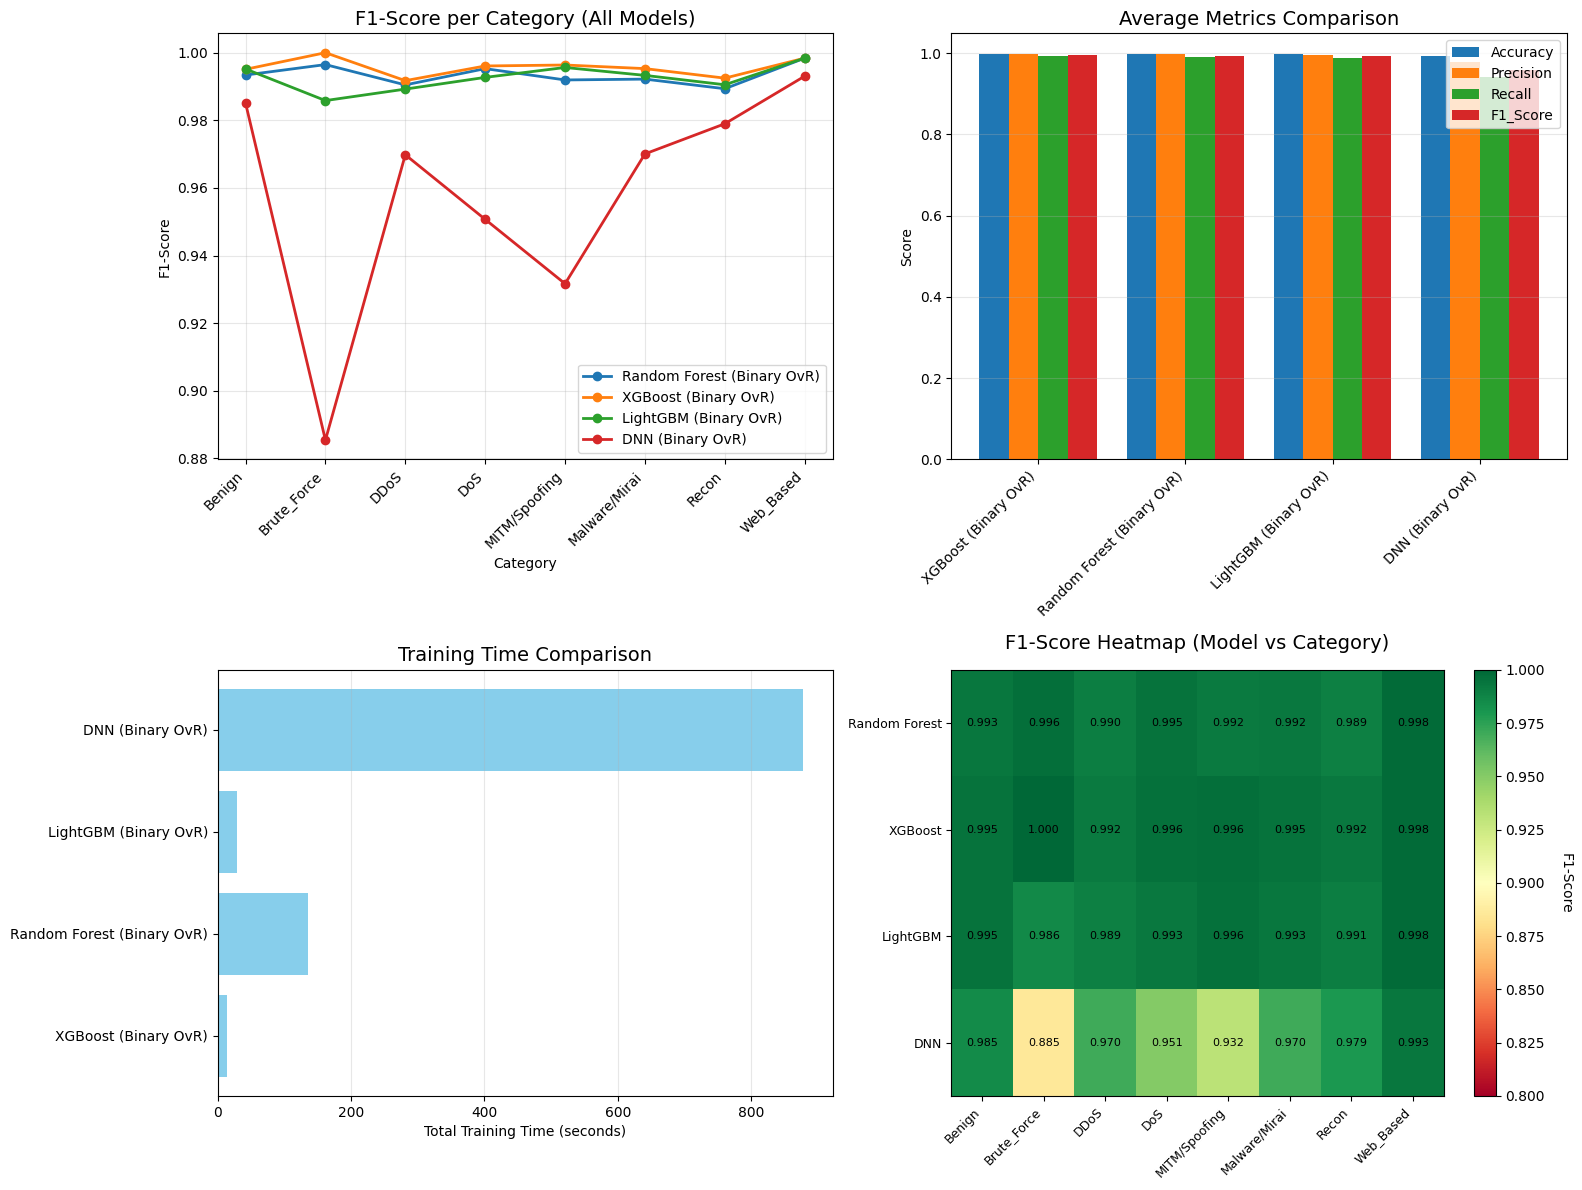


 Visualizations saved!


In [ ]:
# Visualisasi per-category performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: F1-Score per category (all models)
ax1 = axes[0, 0]
for model_result in all_results:
    model_name = model_result['model_name']
    f1_scores = [r['f1_score'] for r in model_result['category_results']]
    ax1.plot(category_names, f1_scores, marker='o', label=model_name, linewidth=2)

ax1.set_xlabel('Category')
ax1.set_ylabel('F1-Score')
ax1.set_title('F1-Score per Category (All Models)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels(category_names, rotation=45, ha='right')

# Plot 2: Average metrics comparison
ax2 = axes[0, 1]
metrics = ['avg_accuracy', 'avg_precision', 'avg_recall', 'avg_f1_score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax2.bar(x + i*width, comparison_df[metric], width,
            label=metric.replace('avg_', '').title())

ax2.set_ylabel('Score')
ax2.set_title('Average Metrics Comparison', fontsize=14)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(comparison_df['model_name'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Training time
ax3 = axes[1, 0]
ax3.barh(comparison_df['model_name'], comparison_df['total_training_time'],
         color='skyblue')
ax3.set_xlabel('Total Training Time (seconds)')
ax3.set_title('Training Time Comparison', fontsize=14)
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Heatmap of F1-scores
ax4 = axes[1, 1]

# Prepare data for heatmap
f1_heatmap_data = []
model_labels = []

for model_result in all_results:
    model_name = model_result['model_name'].replace(' (Binary OvR)', '')
    model_labels.append(model_name)
    f1_scores = [r['f1_score'] for r in model_result['category_results']]
    f1_heatmap_data.append(f1_scores)

f1_heatmap_array = np.array(f1_heatmap_data)

# Create heatmap
im = ax4.imshow(f1_heatmap_array, cmap='RdYlGn', aspect='auto', vmin=0.8, vmax=1.0)

# Set ticks and labels
ax4.set_xticks(np.arange(len(category_names)))
ax4.set_yticks(np.arange(len(model_labels)))
ax4.set_xticklabels(category_names, rotation=45, ha='right', fontsize=9)
ax4.set_yticklabels(model_labels, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('F1-Score', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(model_labels)):
    for j in range(len(category_names)):
        text = ax4.text(j, i, f'{f1_heatmap_array[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=8)

ax4.set_title('F1-Score Heatmap (Model vs Category)', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'binary_ovr_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualizations saved!")

# **Random Split Comparasion (80-20)**

###**RECOVERY CELL 1: Setup Environment Setelah Runtime Terputus**

In [ ]:
print("="*70)
print("RECOVERY MODE: Setting Up Environment")
print("="*70)

# Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import psutil
import os
import gc
from datetime import datetime
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(" All libraries imported!")
print(f"  - TensorFlow: {tf.__version__}")
print(f"  - XGBoost: {xgb.__version__}")
print(f"  - LightGBM: {lgb.__version__}")

RECOVERY MODE: Setting Up Environment
 All libraries imported!
  - TensorFlow: 2.19.0
  - XGBoost: 3.1.2
  - LightGBM: 4.6.0


###**RECOVERY CELL 2: Mount Drive & Setup Paths**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Definisi path (SAMA seperti sebelumnya)
DATASET_PATH = '/content/drive/My Drive/Dataset/final_dataset.parquet'
PROCESSED_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Processed_Data/'
MODELS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Models/'
RESULTS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Results/'
CHECKPOINT_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/Checkpoints/'
EDA_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Binary/EDA_Results/'

print(" Google Drive mounted!")
print(" Paths configured!")

Mounted at /content/drive
 Google Drive mounted!
 Paths configured!


###**RECOVERY CELL 3: Recreate Helper Functions**

In [ ]:
def get_memory_usage():
    """Mendapatkan penggunaan RAM sistem"""
    memory = psutil.virtual_memory()
    used_gb = (memory.total - memory.available) / (1024**3)
    total_gb = memory.total / (1024**3)
    available_gb = memory.available / (1024**3)
    percent = memory.percent
    return used_gb, total_gb, available_gb, percent

def print_memory_status(stage=""):
    """Print status memori"""
    used, total, available, percent = get_memory_usage()
    print(f"\n[Memory Status - {stage}]")
    print(f" Used: {used:.2f} GB / {total:.2f} GB ({percent:.1f}%)")
    print(f" Available: {available:.2f} GB")

def clear_memory():
    """Bersihkan memory"""
    gc.collect()
    print(" Memory cleared")

# BINARY ONE-VS-REST EVALUATION FUNCTIONS
def evaluate_binary_model(y_true, y_pred, y_pred_proba, category_name, model_name, training_time):
    """
    Evaluasi untuk SATU binary classifier (One category vs Rest)

    Parameters:
    -----------
    y_true : array-like (shape: n_samples)
        True binary labels (0 or 1)
    y_pred : array-like (shape: n_samples)
        Predicted binary labels (0 or 1)
    y_pred_proba : array-like (shape: n_samples, 2) or (shape: n_samples)
        Prediction probabilities
    category_name : str
        Nama kategori yang sedang dievaluasi
    model_name : str
        Nama model (RF, XGBoost, etc.)
    training_time : float
        Waktu training dalam detik

    Returns:
    --------
    results : dict
        Metrik evaluasi binary classification
    """
    # Handle probability format
    if len(y_pred_proba.shape) == 2:
        y_prob = y_pred_proba[:, 1]
    else:
        y_prob = y_pred_proba

    # Calculate metrics
    results = {
        'model_name': model_name,
        'category': category_name,
        'training_time_seconds': training_time,

        # Basic metrics
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),

        # Confusion matrix elements
        'tn': None, 'fp': None, 'fn': None, 'tp': None
    }

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        results['tn'] = int(tn)
        results['fp'] = int(fp)
        results['fn'] = int(fn)
        results['tp'] = int(tp)

    # Classification report
    report = classification_report(
        y_true, y_pred,
        target_names=['Negative', 'Positive'],
        output_dict=True,
        zero_division=0
    )

    return results, cm, report

def print_binary_results(results):
    """Print hasil evaluasi binary classifier"""
    print(f"\n{'='*70}")
    print(f"BINARY: {results['model_name']} - {results['category']}")
    print(f"{'='*70}")
    print(f"Training Time: {results['training_time_seconds']:.2f}s")
    print(f"\nMetrics:")
    print(f"  Accuracy  : {results['accuracy']:.4f}")
    print(f"  Precision : {results['precision']:.4f}")
    print(f"  Recall    : {results['recall']:.4f}")
    print(f"  F1-Score  : {results['f1_score']:.4f}")
    print(f"  MCC       : {results['mcc']:.4f}")

    if results['tp'] is not None:
        print(f"\nConfusion Matrix:")
        print(f"  TN={results['tn']:,}  FP={results['fp']:,}")
        print(f"  FN={results['fn']:,}  TP={results['tp']:,}")
    print(f"{'='*70}")

def aggregate_binary_results(all_category_results):
    """
    Aggregate hasil dari semua binary classifiers
    """
    aggregated = {
        'avg_accuracy': np.mean([r['accuracy'] for r in all_category_results]),
        'avg_precision': np.mean([r['precision'] for r in all_category_results]),
        'avg_recall': np.mean([r['recall'] for r in all_category_results]),
        'avg_f1_score': np.mean([r['f1_score'] for r in all_category_results]),
        'avg_mcc': np.mean([r['mcc'] for r in all_category_results]),
        'total_training_time': sum([r['training_time_seconds'] for r in all_category_results]),
        'num_categories': len(all_category_results)
    }

    return aggregated

def create_binary_dnn_model(num_features):
    """DNN untuk BINARY classification"""
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),

        layers.Dense(16, activation='relu'),

        layers.Dense(1, activation='sigmoid')  # BINARY!
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',  # BINARY!
        metrics=['accuracy']
    )

    return model

class LightGBMCallback:
    def __init__(self, total_iterations):
        self.total_iterations = total_iterations
        self.current_iteration = 0
        self.start_time = time.time()

    def __call__(self, env):
        self.current_iteration += 1
        if self.current_iteration % 10 == 0 or self.current_iteration == self.total_iterations:
            progress = (self.current_iteration / self.total_iterations) * 100
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f" Iteration {self.current_iteration}/{self.total_iterations} "
                  f"({progress:.1f}%) - Time: {elapsed:.1f}s - "
                  f"RAM: {percent:.1f}% ({available:.1f} GB available)")

class MemoryLoggingCallback(keras.callbacks.Callback):
    def __init__(self, log_frequency=5):
        super().__init__()
        self.log_frequency = log_frequency
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("\n✓ Training dimulai...")
        print_memory_status("Train Begin")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_frequency == 0:
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f"\nEpoch {epoch + 1}:")
            print(f" Loss: {logs.get('loss'):.4f} - Acc: {logs.get('accuracy'):.4f}")
            print(f" Val Loss: {logs.get('val_loss'):.4f} - Val Acc: {logs.get('val_accuracy'):.4f}")
            print(f" Time: {elapsed:.1f}s - RAM: {percent:.1f}% ({available:.1f} GB available)")

print("All Binary OvR helper functions recreated!")

All Binary OvR helper functions recreated!


###**RECOVERY CELL 4: Load Processed Data (Time-based Split)**

In [ ]:
print("\n" + "="*70)
print("Loading Binary OvR Processed Data dari Google Drive...")
print("="*70)

# Load features (time-based split)
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))

# Load category names
with open(os.path.join(PROCESSED_DIR, 'category_names.json'), 'r') as f:
    category_names = json.load(f)

print(f"Categories: {category_names}")

# Load SEMUA binary labels untuk time-based split
y_train_binary_dict = {}
y_test_binary_dict = {}

for category in category_names:
    safe_name = category.replace('/', '_')

    y_train_binary_dict[category] = np.load(
        os.path.join(PROCESSED_DIR, f'y_train_binary_{safe_name}.npy')
    )
    y_test_binary_dict[category] = np.load(
        os.path.join(PROCESSED_DIR, f'y_test_binary_{safe_name}.npy')
    )

    print(f"  {category}: Train Pos={y_train_binary_dict[category].sum():,}, "
          f"Test Pos={y_test_binary_dict[category].sum():,}")

# Load feature names
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'r') as f:
    feature_names = json.load(f)

# Load preprocessing summary
with open(os.path.join(RESULTS_DIR, 'preprocessing_summary.json'), 'r') as f:
    summary = json.load(f)

print(f"\nBinary OvR data loaded successfully!")
print(f" - X_train: {X_train.shape}")
print(f" - X_test: {X_test.shape}")
print(f" - Binary labels for {len(category_names)} categories")
print(f" - Features: {len(feature_names)}")

print_memory_status("After Loading Data")


Loading Binary OvR Processed Data dari Google Drive...
Categories: ['Benign', 'Brute_Force', 'DDoS', 'DoS', 'MITM/Spoofing', 'Malware/Mirai', 'Recon', 'Web_Based']
  Benign: Train Pos=163,578, Test Pos=15,734
  Brute_Force: Train Pos=4,055, Test Pos=571
  DDoS: Train Pos=45,744, Test Pos=6,097
  DoS: Train Pos=49,107, Test Pos=6,362
  MITM/Spoofing: Train Pos=20,799, Test Pos=2,750
  Malware/Mirai: Train Pos=20,195, Test Pos=2,773
  Recon: Train Pos=76,067, Test Pos=10,096
  Web_Based: Train Pos=6,729, Test Pos=936

Binary OvR data loaded successfully!
 - X_train: (386274, 71)
 - X_test: (45319, 71)
 - Binary labels for 8 categories
 - Features: 71

[Memory Status - After Loading Data]
 Used: 2.99 GB / 50.99 GB (5.9%)
 Available: 48.00 GB


###**RECOVERY CELL 5: Initialize for Random Split Training**

In [ ]:
print("\n" + "="*70)
print("READY FOR RANDOM SPLIT TRAINING!")
print("="*70)

# Initialize results storage
all_results_random = []

print("\nRecovery complete! You can now proceed with:")
print("   - Load Data for Random Split")
print("   - Random Stratified Split")
print("   - Re-normalize Data")
print("   - Training Models with Random Split")

print_memory_status("Recovery Complete")


READY FOR RANDOM SPLIT TRAINING!

Recovery complete! You can now proceed with:
   - Load Data for Random Split
   - Random Stratified Split
   - Re-normalize Data
   - Training Models with Random Split

[Memory Status - Recovery Complete]
 Used: 3.02 GB / 50.99 GB (5.9%)
 Available: 47.97 GB


###**Load Data Original untuk Random Split**

In [ ]:
###Load Data Original untuk Random Split (Binary OvR)
print("\n" + "="*70)
print("BINARY OVR - RANDOM SPLIT COMPARISON")
print("="*70)

print("\nObjective:")
print(" Membandingkan performa Binary OvR dengan strategi split berbeda:")
print(" - Time-based split: windows 1-8 vs 9-10")
print(" - Random stratified split: 80% vs 20%")
print(" Keduanya menggunakan Binary One-vs-Rest approach")

print("\n" + "-"*70)
print("Persiapan Data untuk Random Split (Binary OvR)")
print("-"*70)

print_memory_status("Before Random Split Preparation")

# Combine X dari time-based split
X_all = np.vstack([X_train, X_test])

print(f"\nFeatures combined:")
print(f"   Total samples: {X_all.shape[0]:,}")
print(f"   Features: {X_all.shape[1]}")

# Combine SETIAP binary label
y_binary_all_dict = {}

for category in category_names:
    y_binary_all_dict[category] = np.concatenate([
        y_train_binary_dict[category],
        y_test_binary_dict[category]
    ])

    pos_count = y_binary_all_dict[category].sum()
    neg_count = len(y_binary_all_dict[category]) - pos_count

    print(f"  {category}: Total={len(y_binary_all_dict[category]):,}, "
          f"Pos={pos_count:,} ({pos_count/len(y_binary_all_dict[category])*100:.2f}%), "
          f"Neg={neg_count:,}")

# Verify integrity
assert X_all.shape[0] == len(y_binary_all_dict[category_names[0]]), "Mismatch!"
assert X_all.shape[0] == summary['total_samples_cleaned'], "Data count mismatch!"

print("\nData integrity verified!")
print_memory_status("After Loading Data")


BINARY OVR - RANDOM SPLIT COMPARISON

Objective:
 Membandingkan performa Binary OvR dengan strategi split berbeda:
 - Time-based split: windows 1-8 vs 9-10
 - Random stratified split: 80% vs 20%
 Keduanya menggunakan Binary One-vs-Rest approach

----------------------------------------------------------------------
Persiapan Data untuk Random Split (Binary OvR)
----------------------------------------------------------------------

[Memory Status - Before Random Split Preparation]
 Used: 3.39 GB / 50.99 GB (6.6%)
 Available: 47.60 GB

Features combined:
   Total samples: 431,593
   Features: 71
  Benign: Total=431,593, Pos=179,312 (41.55%), Neg=252,281
  Brute_Force: Total=431,593, Pos=4,626 (1.07%), Neg=426,967
  DDoS: Total=431,593, Pos=51,841 (12.01%), Neg=379,752
  DoS: Total=431,593, Pos=55,469 (12.85%), Neg=376,124
  MITM/Spoofing: Total=431,593, Pos=23,549 (5.46%), Neg=408,044
  Malware/Mirai: Total=431,593, Pos=22,968 (5.32%), Neg=408,625
  Recon: Total=431,593, Pos=86,163 (19

###**Random Stratified Split untuk Binary OvR**

In [ ]:
print("Melakukan Random Stratified Split (80-20) untuk Binary OvR")
print("-"*70)

# STRATEGI: Gunakan salah satu kategori sebagai stratification reference
# untuk memastikan consistent train/test split indices
reference_category = category_names[0]  # 'Benign'

print(f"Using '{reference_category}' as stratification reference...")

# Get stratified indices
train_indices, test_indices = train_test_split(
    np.arange(len(X_all)),
    test_size=0.2,
    random_state=42,
    stratify=y_binary_all_dict[reference_category]
)

print(f"Stratified indices generated:")
print(f"   Train indices: {len(train_indices):,} (80.0%)")
print(f"   Test indices: {len(test_indices):,} (20.0%)")

# Split features
X_train_random = X_all[train_indices]
X_test_random = X_all[test_indices]

print(f"\nFeatures split:")
print(f"   X_train_random: {X_train_random.shape}")
print(f"   X_test_random: {X_test_random.shape}")

# Split SETIAP binary label menggunakan indices yang sama
print(f"\nSplitting binary labels for all {len(category_names)} categories...")
print("-"*70)

y_train_random_binary_dict = {}
y_test_random_binary_dict = {}

for category in category_names:
    y_train_random_binary_dict[category] = y_binary_all_dict[category][train_indices]
    y_test_random_binary_dict[category] = y_binary_all_dict[category][test_indices]

    train_pos = y_train_random_binary_dict[category].sum()
    train_neg = len(y_train_random_binary_dict[category]) - train_pos
    test_pos = y_test_random_binary_dict[category].sum()
    test_neg = len(y_test_random_binary_dict[category]) - test_pos

    print(f"\n{category}:")
    print(f"  Train: Pos={train_pos:,} ({train_pos/len(X_train_random)*100:.2f}%), "
          f"Neg={train_neg:,}")
    print(f"  Test:  Pos={test_pos:,} ({test_pos/len(X_test_random)*100:.2f}%), "
          f"Neg={test_neg:,}")

print("\n" + "="*70)
print("Random stratified split complete for Binary OvR!")
print("="*70)

# Verify data integrity
assert X_train_random.shape[0] == len(y_train_random_binary_dict[category_names[0]])
assert X_test_random.shape[0] == len(y_test_random_binary_dict[category_names[0]])

print(f"\nSplit integrity verified!")

print_memory_status("After Random Split")

Melakukan Random Stratified Split (80-20) untuk Binary OvR
----------------------------------------------------------------------
Using 'Benign' as stratification reference...
Stratified indices generated:
   Train indices: 345,274 (80.0%)
   Test indices: 86,319 (20.0%)

Features split:
   X_train_random: (345274, 71)
   X_test_random: (86319, 71)

Splitting binary labels for all 8 categories...
----------------------------------------------------------------------

Benign:
  Train: Pos=143,449 (41.55%), Neg=201,825
  Test:  Pos=35,863 (41.55%), Neg=50,456

Brute_Force:
  Train: Pos=3,689 (1.07%), Neg=341,585
  Test:  Pos=937 (1.09%), Neg=85,382

DDoS:
  Train: Pos=41,511 (12.02%), Neg=303,763
  Test:  Pos=10,330 (11.97%), Neg=75,989

DoS:
  Train: Pos=44,394 (12.86%), Neg=300,880
  Test:  Pos=11,075 (12.83%), Neg=75,244

MITM/Spoofing:
  Train: Pos=18,768 (5.44%), Neg=326,506
  Test:  Pos=4,781 (5.54%), Neg=81,538

Malware/Mirai:
  Train: Pos=18,409 (5.33%), Neg=326,865
  Test:  Pos=

###**Re-normalize Data untuk Random Split**

In [ ]:
print("Re-normalize Data untuk Random Split")
print("-"*70)

# Fit new scaler pada random train set
scaler_random = StandardScaler()
X_train_random_scaled = scaler_random.fit_transform(X_train_random)
X_test_random_scaled = scaler_random.transform(X_test_random)

print(f"Data normalized dengan StandardScaler")
print(f"   Mean: {X_train_random_scaled.mean():.10f}")
print(f"   Std: {X_train_random_scaled.std():.10f}")

# Save random split data
print("\nMenyimpan random split data...")
np.save(os.path.join(PROCESSED_DIR, 'X_train_random.npy'), X_train_random_scaled)
np.save(os.path.join(PROCESSED_DIR, 'X_test_random.npy'), X_test_random_scaled)

# Save binary labels
for category in category_names:
    safe_name = category.replace('/', '_')
    np.save(os.path.join(PROCESSED_DIR, f'y_train_random_binary_{safe_name}.npy'),
            y_train_random_binary_dict[category])
    np.save(os.path.join(PROCESSED_DIR, f'y_test_random_binary_{safe_name}.npy'),
            y_test_random_binary_dict[category])

with open(os.path.join(PROCESSED_DIR, 'scaler_random.pkl'), 'wb') as f:
    pickle.dump(scaler_random, f)

print("Random split data tersimpan!")

Re-normalize Data untuk Random Split
----------------------------------------------------------------------
Data normalized dengan StandardScaler
   Mean: 0.0000000000
   Std: 1.0000000000

Menyimpan random split data...
Random split data tersimpan!


###**Initialize Results Storage untuk Random Split**

In [ ]:
print("Training Models dengan Random Split")
print("-"*70)

# Initialize list untuk menyimpan hasil random split
all_results_random = []

print("Ready to train models on random split!")

Training Models dengan Random Split
----------------------------------------------------------------------
Ready to train models on random split!


###**Training Random Forest (Random Split)**

In [ ]:
print("Training Models dengan Random Split (Binary OvR)")
print("="*70)
print("TRAINING RANDOM FOREST - BINARY ONE-VS-REST")
print("="*70)

print_memory_status("Before RF Random OvR")

# Initialize results storage
all_results_random = []

# Storage untuk RF
rf_results_all_categories = []
rf_models_random = {}

# Loop untuk setiap kategori
for idx, category in enumerate(category_names, 1):
    print(f"\n{'='*70}")
    print(f"[{idx}/{len(category_names)}] Training RF untuk: {category}")
    print(f"{'='*70}")

    # Get binary labels
    y_train_cat = y_train_random_binary_dict[category]
    y_test_cat = y_test_random_binary_dict[category]

    # Train RF
    start_time = time.time()

    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    print(f"Training...")
    rf_model.fit(X_train_random_scaled, y_train_cat)
    training_time = time.time() - start_time

    print(f"Done: {training_time:.2f}s")

    # Prediction
    y_pred_cat = rf_model.predict(X_test_random_scaled)
    y_pred_proba_cat = rf_model.predict_proba(X_test_random_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "Random Forest", training_time
    )

    print_binary_results(results)

    rf_results_all_categories.append(results)
    rf_models_random[category] = rf_model

    # Save individual model
    safe_name = category.replace('/', '_')
    with open(os.path.join(MODELS_DIR, f'rf_random_binary_{safe_name}.pkl'), 'wb') as f:
        pickle.dump(rf_model, f)

    clear_memory()

# Aggregate results
print(f"\n{'='*70}")
print("RF - AGGREGATED RESULTS (Random Split)")
print(f"{'='*70}")

rf_aggregated_random = aggregate_binary_results(rf_results_all_categories)
print(f"\nAverage Metrics:")
print(f"  Accuracy  : {rf_aggregated_random['avg_accuracy']:.4f}")
print(f"  Precision : {rf_aggregated_random['avg_precision']:.4f}")
print(f"  Recall    : {rf_aggregated_random['avg_recall']:.4f}")
print(f"  F1-Score  : {rf_aggregated_random['avg_f1_score']:.4f}")
print(f"  MCC       : {rf_aggregated_random['avg_mcc']:.4f}")
print(f"\nTotal Training Time: {rf_aggregated_random['total_training_time']:.2f}s")

# Save
rf_aggregated_random['model_name'] = 'Random Forest (Random Split)'
rf_aggregated_random['category_results'] = rf_results_all_categories
all_results_random.append(rf_aggregated_random)

with open(os.path.join(RESULTS_DIR, 'rf_random_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': rf_aggregated_random,
        'per_category': rf_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After RF Random OvR")

Training Models dengan Random Split (Binary OvR)
TRAINING RANDOM FOREST - BINARY ONE-VS-REST

[Memory Status - Before RF Random OvR]
 Used: 3.96 GB / 50.99 GB (7.8%)
 Available: 47.03 GB

[1/8] Training RF untuk: Benign
Training...
Done: 18.66s

BINARY: Random Forest - Benign
Training Time: 18.66s

Metrics:
  Accuracy  : 0.9883
  Precision : 0.9737
  Recall    : 0.9989
  F1-Score  : 0.9861
  MCC       : 0.9763

Confusion Matrix:
  TN=49,490  FP=966
  FN=41  TP=35,822
 Memory cleared

[2/8] Training RF untuk: Brute_Force
Training...
Done: 17.38s

BINARY: Random Forest - Brute_Force
Training Time: 17.38s

Metrics:
  Accuracy  : 0.9994
  Precision : 1.0000
  Recall    : 0.9434
  F1-Score  : 0.9709
  MCC       : 0.9710

Confusion Matrix:
  TN=85,382  FP=0
  FN=53  TP=884
 Memory cleared

[3/8] Training RF untuk: DDoS
Training...
Done: 28.01s

BINARY: Random Forest - DDoS
Training Time: 28.01s

Metrics:
  Accuracy  : 0.9948
  Precision : 0.9985
  Recall    : 0.9584
  F1-Score  : 0.9780
  MC

###**Training XGBoost (Random Split)**

In [ ]:
print("\n" + "="*70)
print("TRAINING XGBOOST - BINARY ONE-VS-REST")
print("="*70)

print_memory_status("Before XGBoost Random OvR")

xgb_results_all_categories = []
xgb_models_random = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n{'='*70}")
    print(f"[{idx}/{len(category_names)}] Training XGBoost untuk: {category}")
    print(f"{'='*70}")

    y_train_cat = y_train_random_binary_dict[category]
    y_test_cat = y_test_random_binary_dict[category]

    start_time = time.time()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',  # BINARY!
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42,
        n_jobs=-1
    )

    print(f" Training...")
    try:
        xgb_model.fit(X_train_random_scaled, y_train_cat, verbose=False)
    except Exception as e:
        print(f" GPU failed, switching to CPU...")
        xgb_model.set_params(device='cpu')
        xgb_model.fit(X_train_random_scaled, y_train_cat, verbose=False)

    training_time = time.time() - start_time
    print(f" Done: {training_time:.2f}s")

    # Prediction
    y_pred_cat = xgb_model.predict(X_test_random_scaled)
    y_pred_proba_cat = xgb_model.predict_proba(X_test_random_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "XGBoost", training_time
    )

    print_binary_results(results)

    xgb_results_all_categories.append(results)
    xgb_models_random[category] = xgb_model

    # Save
    safe_name = category.replace('/', '_')
    xgb_model.save_model(os.path.join(MODELS_DIR, f'xgb_random_binary_{safe_name}.json'))

    clear_memory()

# Aggregate
print(f"\n{'='*70}")
print("XGBOOST - AGGREGATED RESULTS")
print(f"{'='*70}")

xgb_aggregated_random = aggregate_binary_results(xgb_results_all_categories)
print(f"\nAverage Metrics:")
print(f"  Accuracy  : {xgb_aggregated_random['avg_accuracy']:.4f}")
print(f"  F1-Score  : {xgb_aggregated_random['avg_f1_score']:.4f}")
print(f"\nTotal Time: {xgb_aggregated_random['total_training_time']:.2f}s")

xgb_aggregated_random['model_name'] = 'XGBoost (Random Split)'
xgb_aggregated_random['category_results'] = xgb_results_all_categories
all_results_random.append(xgb_aggregated_random)

with open(os.path.join(RESULTS_DIR, 'xgb_random_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': xgb_aggregated_random,
        'per_category': xgb_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After XGBoost Random OvR")


TRAINING XGBOOST - BINARY ONE-VS-REST

[Memory Status - Before XGBoost Random OvR]
 Used: 4.34 GB / 50.99 GB (8.5%)
 Available: 46.66 GB

[1/8] Training XGBoost untuk: Benign
 Training...
 Done: 2.14s

BINARY: XGBoost - Benign
Training Time: 2.14s

Metrics:
  Accuracy  : 0.9901
  Precision : 0.9780
  Recall    : 0.9986
  F1-Score  : 0.9882
  MCC       : 0.9798

Confusion Matrix:
  TN=49,651  FP=805
  FN=52  TP=35,811
 Memory cleared

[2/8] Training XGBoost untuk: Brute_Force
 Training...
 Done: 1.50s

BINARY: XGBoost - Brute_Force
Training Time: 1.50s

Metrics:
  Accuracy  : 0.9996
  Precision : 0.9945
  Recall    : 0.9648
  F1-Score  : 0.9794
  MCC       : 0.9793

Confusion Matrix:
  TN=85,377  FP=5
  FN=33  TP=904
 Memory cleared

[3/8] Training XGBoost untuk: DDoS
 Training...
 Done: 1.81s

BINARY: XGBoost - DDoS
Training Time: 1.81s

Metrics:
  Accuracy  : 0.9959
  Precision : 0.9960
  Recall    : 0.9692
  F1-Score  : 0.9824
  MCC       : 0.9802

Confusion Matrix:
  TN=75,949  FP=

###**Training LightGBM (Random Split)**

In [ ]:
print("\n" + "="*70)
print("TRAINING LIGHTGBM - BINARY ONE-VS-REST")
print("="*70)

print_memory_status("Before LightGBM Random OvR")

lgb_results_all_categories = []
lgb_models_random = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n[{idx}/{len(category_names)}] Training LightGBM: {category}")

    y_train_cat = y_train_random_binary_dict[category]
    y_test_cat = y_test_random_binary_dict[category]

    start_time = time.time()

    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary',  # BINARY!
        device='gpu',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    print(f" Training...")
    try:
        lgb_model.fit(X_train_random_scaled, y_train_cat)
    except Exception as e:
        print(f" GPU failed: {e}, switching to CPU...")
        lgb_model.set_params(device='cpu')
        lgb_model.fit(X_train_random_scaled, y_train_cat)

    training_time = time.time() - start_time
    print(f" Done: {training_time:.2f}s")

    # Prediction
    y_pred_cat = lgb_model.predict(X_test_random_scaled)
    y_pred_proba_cat = lgb_model.predict_proba(X_test_random_scaled)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "LightGBM", training_time
    )

    print_binary_results(results)

    lgb_results_all_categories.append(results)
    lgb_models_random[category] = lgb_model

    # Save
    safe_name = category.replace('/', '_')
    with open(os.path.join(MODELS_DIR, f'lgb_random_binary_{safe_name}.pkl'), 'wb') as f:
        pickle.dump(lgb_model, f)

    clear_memory()

# Aggregate
print(f"\n{'='*70}")
print("LIGHTGBM - AGGREGATED RESULTS")
print(f"{'='*70}")

lgb_aggregated_random = aggregate_binary_results(lgb_results_all_categories)
print(f"\nAverage Metrics:")
print(f"  Accuracy  : {lgb_aggregated_random['avg_accuracy']:.4f}")
print(f"  F1-Score  : {lgb_aggregated_random['avg_f1_score']:.4f}")
print(f"\nTotal Time: {lgb_aggregated_random['total_training_time']:.2f}s")

lgb_aggregated_random['model_name'] = 'LightGBM (Random Split)'
lgb_aggregated_random['category_results'] = lgb_results_all_categories
all_results_random.append(lgb_aggregated_random)

with open(os.path.join(RESULTS_DIR, 'lgb_random_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': lgb_aggregated_random,
        'per_category': lgb_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After LightGBM Random OvR")


TRAINING LIGHTGBM - BINARY ONE-VS-REST

[Memory Status - Before LightGBM Random OvR]
 Used: 6.15 GB / 50.99 GB (12.1%)
 Available: 44.84 GB

[1/8] Training LightGBM: Benign
 Training...
 GPU failed: Check failed: (best_split_info.right_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 862 .
, switching to CPU...
 Done: 4.83s

BINARY: LightGBM - Benign
Training Time: 4.83s

Metrics:
  Accuracy  : 0.9901
  Precision : 0.9782
  Recall    : 0.9985
  F1-Score  : 0.9882
  MCC       : 0.9798

Confusion Matrix:
  TN=49,657  FP=799
  FN=55  TP=35,808
 Memory cleared

[2/8] Training LightGBM: Brute_Force
 Training...
 Done: 4.16s

BINARY: LightGBM - Brute_Force
Training Time: 4.16s

Metrics:
  Accuracy  : 0.9995
  Precision : 0.9912
  Recall    : 0.9605
  F1-Score  : 0.9756
  MCC       : 0.9755

Confusion Matrix:
  TN=85,374  FP=8
  FN=37  TP=900
 Memory cleared

[3/8] Training LightGBM: DDoS
 Training...
 Done: 2.45s

BINARY: LightGBM - DDoS
Training Time: 

###**Training DNN (Random Split)**

In [ ]:
print("\n" + "="*70)
print("TRAINING DNN - BINARY ONE-VS-REST")
print("="*70)

print_memory_status("Before DNN Random OvR")
clear_memory()

num_features = X_train_random_scaled.shape[1]

dnn_results_all_categories = []
dnn_models_random = {}

for idx, category in enumerate(category_names, 1):
    print(f"\n[{idx}/{len(category_names)}] Training DNN: {category}")

    y_train_cat = y_train_random_binary_dict[category]
    y_test_cat = y_test_random_binary_dict[category]

    dnn_model = create_binary_dnn_model(num_features)

    checkpoint = ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, f'dnn_random_binary_{category.replace("/", "_")}.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )

    start_time = time.time()

    history = dnn_model.fit(
        X_train_random_scaled, y_train_cat,
        validation_split=0.1,
        epochs=50,
        batch_size=256,
        callbacks=[
            checkpoint,
            EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
            MemoryLoggingCallback(log_frequency=10)
        ],
        verbose=0
    )

    training_time = time.time() - start_time
    print(f" Done: {training_time:.2f}s")

    # Prediction
    y_pred_proba_cat = dnn_model.predict(X_test_random_scaled, verbose=0).flatten()
    y_pred_cat = (y_pred_proba_cat > 0.5).astype(int)

    # Evaluation
    results, cm, report = evaluate_binary_model(
        y_test_cat, y_pred_cat, y_pred_proba_cat,
        category, "DNN", training_time
    )

    print_binary_results(results)

    dnn_results_all_categories.append(results)
    dnn_models_random[category] = dnn_model

    clear_memory()

# Aggregate
dnn_aggregated_random = aggregate_binary_results(dnn_results_all_categories)
print(f"\nDNN Average F1: {dnn_aggregated_random['avg_f1_score']:.4f}")

dnn_aggregated_random['model_name'] = 'DNN (Random Split)'
dnn_aggregated_random['category_results'] = dnn_results_all_categories
all_results_random.append(dnn_aggregated_random)

with open(os.path.join(RESULTS_DIR, 'dnn_random_binary_ovr_results.json'), 'w') as f:
    json.dump({
        'aggregated': dnn_aggregated_random,
        'per_category': dnn_results_all_categories
    }, f, indent=4, default=int)

print_memory_status("After DNN Random OvR")


TRAINING DNN - BINARY ONE-VS-REST

[Memory Status - Before DNN Random OvR]
 Used: 5.05 GB / 50.99 GB (9.9%)
 Available: 45.94 GB
 Memory cleared

[1/8] Training DNN: Benign

✓ Training dimulai...

[Memory Status - Train Begin]
 Used: 5.30 GB / 50.99 GB (10.4%)
 Available: 45.69 GB

Epoch 10:
 Loss: 0.0573 - Acc: 0.9796
 Val Loss: 0.0488 - Val Acc: 0.9831
 Time: 40.0s - RAM: 10.3% (45.7 GB available)

Epoch 20:
 Loss: 0.0550 - Acc: 0.9804
 Val Loss: 0.0471 - Val Acc: 0.9835
 Time: 70.8s - RAM: 10.0% (45.9 GB available)

Epoch 30:
 Loss: 0.0514 - Acc: 0.9817
 Val Loss: 0.0465 - Val Acc: 0.9832
 Time: 100.6s - RAM: 9.9% (46.0 GB available)
 Done: 127.90s

BINARY: DNN - Benign
Training Time: 127.90s

Metrics:
  Accuracy  : 0.9843
  Precision : 0.9671
  Recall    : 0.9961
  F1-Score  : 0.9814
  MCC       : 0.9681

Confusion Matrix:
  TN=49,240  FP=1,216
  FN=140  TP=35,723
 Memory cleared

[2/8] Training DNN: Brute_Force

✓ Training dimulai...

[Memory Status - Train Begin]
 Used: 5.22 GB 

###**Comparison Table - Time-based vs Random Split**

In [ ]:
print("\n" + "="*70)
print("COMPARISON: TIME-BASED vs RANDOM (Binary OvR)")
print("="*70)

# Create comparison dataframe untuk random split
comparison_df_random = pd.DataFrame([
    {
        'model_name': r['model_name'],
        'avg_accuracy': r['avg_accuracy'],
        'avg_precision': r['avg_precision'],
        'avg_recall': r['avg_recall'],
        'avg_f1_score': r['avg_f1_score'],
        'avg_mcc': r['avg_mcc'],
        'total_training_time': r['total_training_time']
    } for r in all_results_random
])

comparison_df_random = comparison_df_random.sort_values('avg_f1_score', ascending=False)

print("\nRESULTS - RANDOM SPLIT (Binary OvR):")
print(comparison_df_random.to_string(index=False))

# Save
comparison_df_random.to_csv(
    os.path.join(RESULTS_DIR, 'binary_ovr_comparison_random.csv'),
    index=False
)

# Load time-based comparison
comparison_file_tb = os.path.join(RESULTS_DIR, 'binary_ovr_comparison.csv')
if os.path.exists(comparison_file_tb):
    comparison_df_timebased = pd.read_csv(comparison_file_tb)

    print("\nRESULTS - TIME-BASED SPLIT (Binary OvR):")
    print(comparison_df_timebased.to_string(index=False))

    # Create side-by-side comparison
    print("\n" + "="*70)
    print("SIDE-BY-SIDE COMPARISON")
    print("="*70)

    model_names = ['Random Forest', 'XGBoost', 'LightGBM', 'DNN']

    for model_name in model_names:
        tb_row = comparison_df_timebased[
            comparison_df_timebased['model_name'].str.contains(model_name, case=False)
        ]
        r_row = comparison_df_random[
            comparison_df_random['model_name'].str.contains(model_name, case=False)
        ]

        if not tb_row.empty and not r_row.empty:
            print(f"\n{model_name}:")
            print(f"  Time-based F1: {tb_row['avg_f1_score'].values[0]:.4f}")
            print(f"  Random F1:     {r_row['avg_f1_score'].values[0]:.4f}")
            print(f"  Difference:    {r_row['avg_f1_score'].values[0] - tb_row['avg_f1_score'].values[0]:+.4f}")
else:
    print("\nTime-based Binary OvR comparison not found.")
    print("   Train time-based split first with Binary OvR approach.")

print("\nComparison complete!")


COMPARISON: TIME-BASED vs RANDOM (Binary OvR)

RESULTS - RANDOM SPLIT (Binary OvR):
                  model_name  avg_accuracy  avg_precision  avg_recall  avg_f1_score  avg_mcc  total_training_time
      XGBoost (Random Split)      0.996306       0.992141    0.977638      0.984768 0.982358            13.096994
     LightGBM (Random Split)      0.996070       0.991164    0.975145      0.983019 0.980487            25.683496
     LightGBM (Random Split)      0.996068       0.991163    0.975134      0.983013 0.980480            27.792289
Random Forest (Random Split)      0.995431       0.993974    0.967030      0.980157 0.977319           180.887989
          DNN (Random Split)      0.991188       0.967078    0.911408      0.936193 0.932251           879.944293

RESULTS - TIME-BASED SPLIT (Binary OvR):
                model_name  avg_accuracy  avg_precision  avg_recall  avg_f1_score  avg_mcc  total_training_time  num_categories
      XGBoost (Binary OvR)      0.998607       0.997545    0.